In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import calendar
np.random.seed(42)

In [2]:
ORDER_PATH = "/Users/michaelmurphy/Desktop/usgs_data/nhd_id_stream_order_permanence.csv"
OBS_PATH = "/Users/michaelmurphy/Desktop/usgs_data/obs.parquet"
stream_order = pd.read_csv(ORDER_PATH)
obs_df = pd.read_parquet(OBS_PATH)

DAY_1_PATH = "/Users/michaelmurphy/Desktop/usgs_data/train_val_pred_c/train_val_predictions_day1.csv"
DAY_2_PATH = "/Users/michaelmurphy/Desktop/usgs_data/train_val_pred_c/train_val_predictions_day2.csv"
DAY_3_PATH = "/Users/michaelmurphy/Desktop/usgs_data/train_val_pred_c/train_val_predictions_day3.csv"
WINDOW_SPLIT_PATH = "/Users/michaelmurphy/Desktop/usgs_data/window_split_map.csv"

day_1_df = pd.read_csv(DAY_1_PATH)
day_2_df = pd.read_csv(DAY_2_PATH)
day_3_df = pd.read_csv(DAY_3_PATH)

# Load new window-based split and apply to all dfs
split_map = pd.read_csv(WINDOW_SPLIT_PATH)
for df in [day_1_df, day_2_df, day_3_df]:
    df["split"] = df["window_index"].map(split_map.set_index("window_index")["split"])

print(f"Split distribution (day_1_df):")
print(day_1_df["split"].value_counts())
day_1_df

Split distribution (day_1_df):
split
train    3013400
val       754143
Name: count, dtype: int64


,Unnamed: 0,window_index,horizon_step,date,site_id,has_true_label,static__ArbolateSu,static__AreaSqKm,static__LengthKM,static__Slope,...,feature__month,feature__day,true_wetdry,true_discharge_log,true_discharge_cms,pred_wetdry_prob,pred_wetdry_label,pred_discharge_log,pred_discharge_cms,split
0,0,0,1,1980-01-29,55000900026515,0,0.384934,0.0929,0.384934,0.143402,...,0.0,0.0,NaN,NaN,NaN,0.524898,1,-0.024400,-0.024105,train
1,1,0,1,1980-01-29,55000900027171,0,0.100818,0.0017,0.100818,0.000010,...,0.0,0.0,NaN,NaN,NaN,0.524898,1,-0.024400,-0.024105,train
2,2,0,1,1980-01-29,55000900027172,0,1.891027,0.0019,0.038352,0.391115,...,0.0,0.0,NaN,NaN,NaN,0.565396,1,0.171712,0.187336,train
3,3,0,1,1980-01-29,55000900027173,0,0.297666,0.1235,0.147160,0.376460,...,0.0,0.0,NaN,NaN,NaN,0.656484,1,-0.037942,-0.037231,train
4,4,0,1,1980-01-29,55000900027174,0,0.410513,0.0923,0.410513,0.424846,...,0.0,0.0,NaN,NaN,NaN,0.524898,1,-0.024400,-0.024105,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3767538,3767538,11,1,2020-12-02,55000900272712,0,0.798829,0.2351,0.798829,0.337851,...,0.0,0.0,NaN,NaN,NaN,0.524898,1,-0.024400,-0.024105,train
3767539,3767539,11,1,2020-12-02,55000900272713,0,4.874749,0.0670,0.125972,0.080018,...,0.0,0.0,NaN,NaN,NaN,0.742405,1,0.467956,0.596727,train
3767540,3767540,11,1,2020-12-02,55000900272714,0,1.827595,0.3093,1.137816,0.215975,...,0.0,0.0,NaN,NaN,NaN,0.547348,1,-0.053526,-0.052118,train
3767541,3767541,11,1,2020-12-02,55000900272715,0,0.159997,0.1874,0.159997,0.490190,...,0.0,0.0,NaN,NaN,NaN,0.524898,1,-0.024400,-0.024105,train


## Validation Metrics — Wet/Dry Classification

In [3]:
# Prepare validation data for each horizon + aggregated (val split only)
horizon_dfs = {}
for name, raw_df in [("Day 1", day_1_df), ("Day 2", day_2_df), ("Day 3", day_3_df)]:
    df = raw_df[(raw_df["has_true_label"] == True) & (raw_df["split"] == "val")].copy()
    df = df.merge(stream_order[["NHDPlusID", "StreamOrde"]], left_on="site_id", right_on="NHDPlusID", how="left")
    horizon_dfs[name] = df

all_horizons = pd.concat(horizon_dfs.values(), ignore_index=True)
horizon_dfs["All Horizons"] = all_horizons


def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float("nan")
    f1_val = f1_score(y_true, y_pred, zero_division=0)
    return acc, roc, f1_val


group_filters = {
    "All": lambda df: df,
    "Headwaters (≤2)": lambda df: df[df["StreamOrde"] <= 2],
    "Tailwaters (≥3)": lambda df: df[df["StreamOrde"] >= 3],
}

print("Validation samples per horizon:")
for name, df in horizon_dfs.items():
    hw = (df["StreamOrde"] <= 2).sum()
    tw = (df["StreamOrde"] >= 3).sum()
    print(f"  {name:>14s}: {len(df):,} total  |  HW (≤2): {hw:,}  |  TW (≥3): {tw:,}")

Validation samples per horizon:
           Day 1: 7,449 total  |  HW (≤2): 3,635  |  TW (≥3): 3,814
           Day 2: 7,455 total  |  HW (≤2): 3,641  |  TW (≥3): 3,814
           Day 3: 7,453 total  |  HW (≤2): 3,639  |  TW (≥3): 3,814
    All Horizons: 22,357 total  |  HW (≤2): 10,915  |  TW (≥3): 11,442


In [4]:
# Summary metrics: Horizon × Group (All / Headwaters / Tailwaters)
rows = []
for h_name, h_df in horizon_dfs.items():
    for g_name, g_filter in group_filters.items():
        subset = g_filter(h_df)
        if len(subset) == 0:
            continue
        y_t = subset["true_wetdry"].values
        y_p = subset["pred_wetdry_label"].values
        acc, roc, f1_val = compute_metrics(y_t, y_p)
        rows.append({
            "Horizon": h_name, "Group": g_name, "N": len(subset),
            "Accuracy": acc, "ROC-AUC": roc, "F1": f1_val,
        })

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

     Horizon           Group     N  Accuracy  ROC-AUC       F1
       Day 1             All  7449  0.992751 0.886518 0.996302
       Day 1 Headwaters (≤2)  3635  0.987070 0.903315 0.993267
       Day 1 Tailwaters (≥3)  3814  0.998165 0.500000 0.999081
       Day 2             All  7455  0.992220 0.861452 0.996030
       Day 2 Headwaters (≤2)  3641  0.986268 0.876545 0.992847
       Day 2 Tailwaters (≥3)  3814  0.997902 0.499869 0.998950
       Day 3             All  7453  0.993291 0.881893 0.996577
       Day 3 Headwaters (≤2)  3639  0.988458 0.900240 0.993991
       Day 3 Tailwaters (≥3)  3814  0.997902 0.555556 0.998950
All Horizons             All 22357  0.992754 0.876337 0.996303
All Horizons Headwaters (≤2) 10915  0.987265 0.893013 0.993369
All Horizons Tailwaters (≥3) 11442  0.997990 0.521695 0.998994


In [5]:
# Classification reports per horizon × group
for h_name, h_df in horizon_dfs.items():
    for g_name, g_filter in group_filters.items():
        subset = g_filter(h_df)
        if len(subset) == 0:
            continue
        y_t = subset["true_wetdry"].values
        y_p = subset["pred_wetdry_label"].values
        print(f"\n{'='*55}")
        print(f"{h_name} — {g_name} (n={len(subset)})")
        print("=" * 55)
        print(classification_report(
            y_t, y_p, labels=[0, 1],
            target_names=["Dry", "Wet"], digits=3, zero_division=0
        ))


Day 1 — All (n=7449)
              precision    recall  f1-score   support

         Dry      0.864     0.776     0.818       156
         Wet      0.995     0.997     0.996      7293

    accuracy                          0.993      7449
   macro avg      0.930     0.887     0.907      7449
weighted avg      0.992     0.993     0.993      7449


Day 1 — Headwaters (≤2) (n=3635)
              precision    recall  f1-score   support

         Dry      0.864     0.812     0.837       149
         Wet      0.992     0.995     0.993      3486

    accuracy                          0.987      3635
   macro avg      0.928     0.903     0.915      3635
weighted avg      0.987     0.987     0.987      3635


Day 1 — Tailwaters (≥3) (n=3814)
              precision    recall  f1-score   support

         Dry      0.000     0.000     0.000         7
         Wet      0.998     1.000     0.999      3807

    accuracy                          0.998      3814
   macro avg      0.499     0.500     

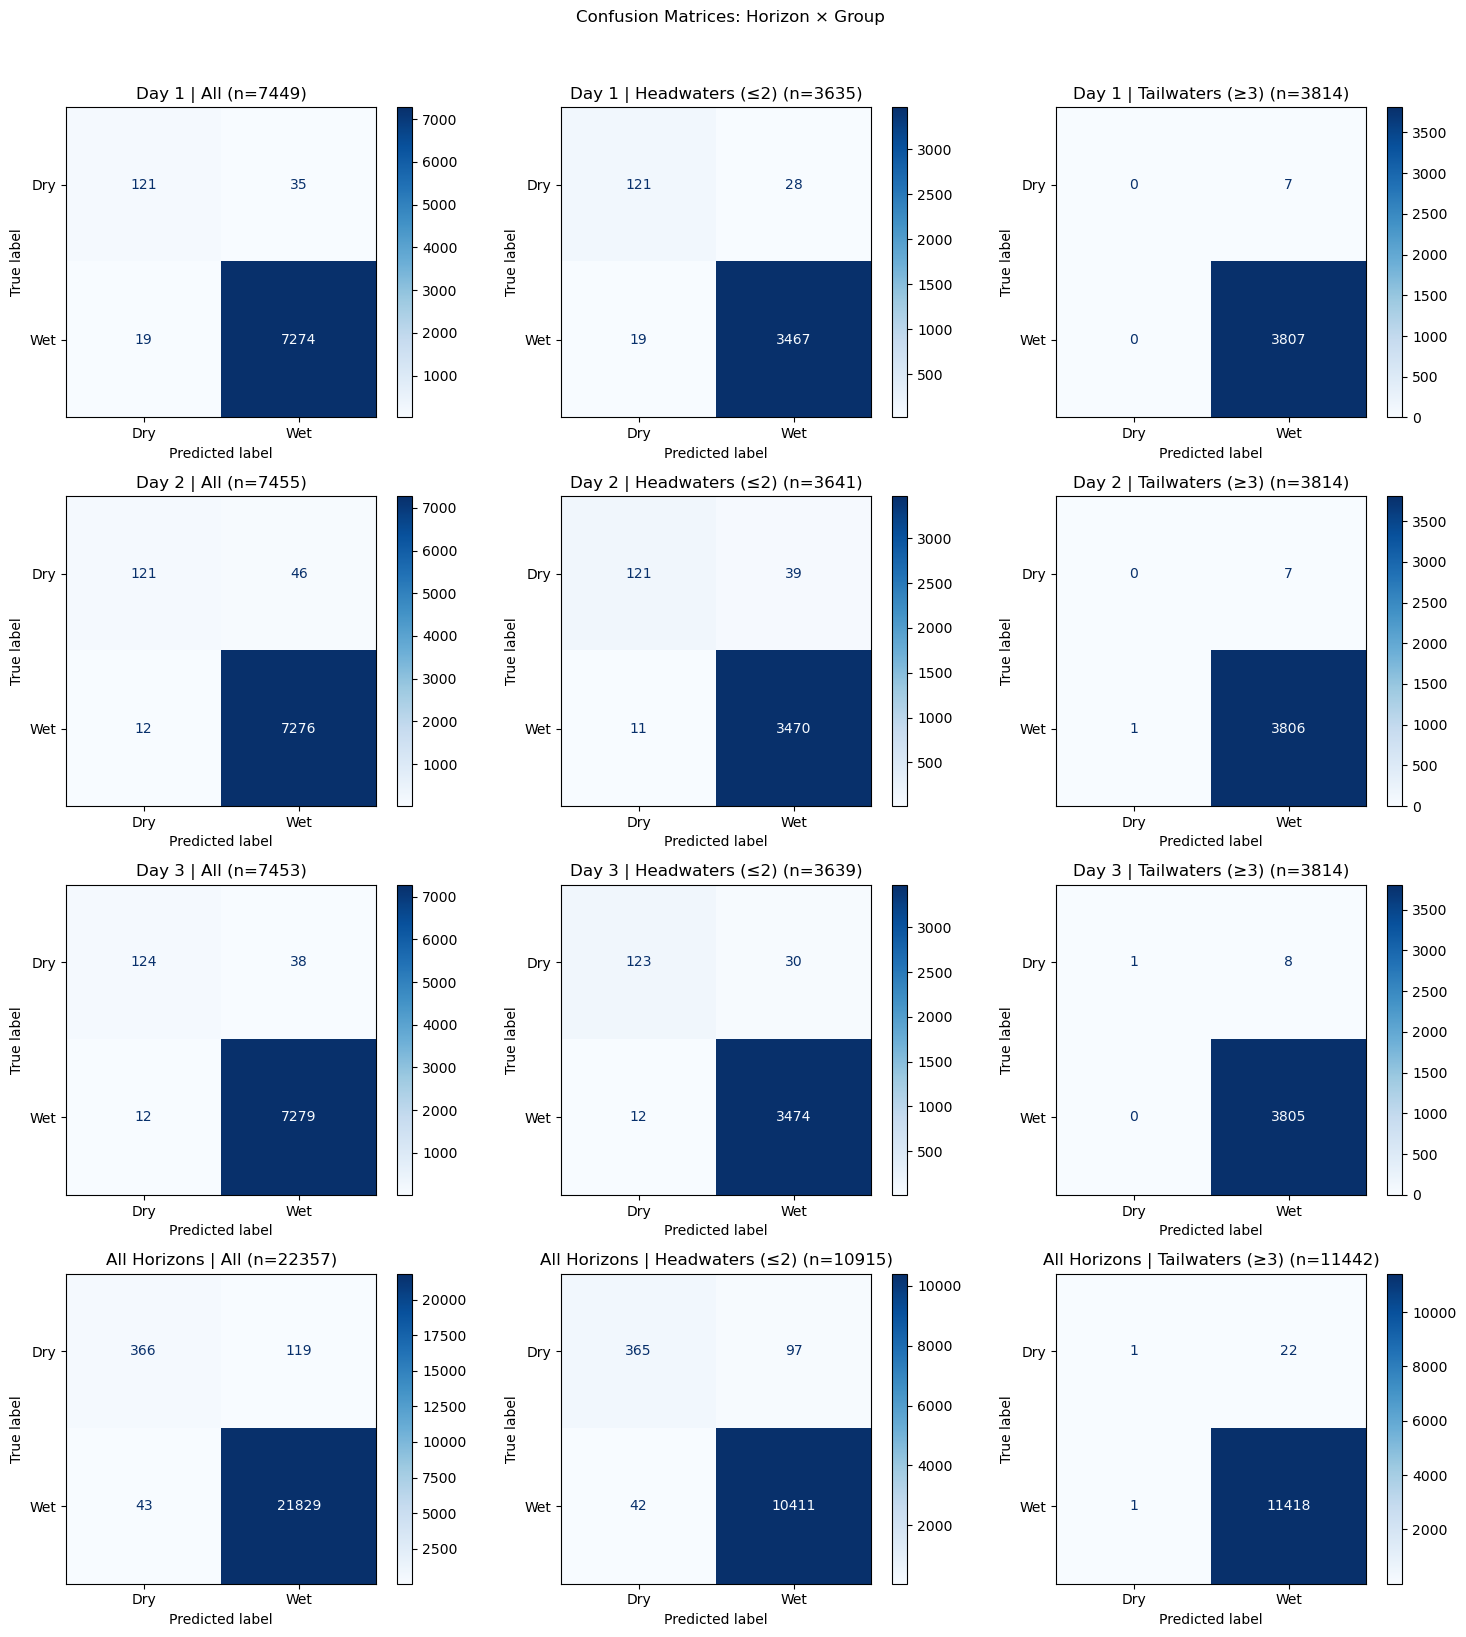

In [6]:
# Confusion matrices: Horizon × Group (All / Headwaters / Tailwaters)
horizon_names = list(horizon_dfs.keys())
group_names = list(group_filters.keys())

fig, axes = plt.subplots(
    len(horizon_names), len(group_names),
    figsize=(5 * len(group_names), 4 * len(horizon_names)),
)

for row_idx, h_name in enumerate(horizon_names):
    h_df = horizon_dfs[h_name]
    for col_idx, (g_name, g_filter) in enumerate(group_filters.items()):
        ax = axes[row_idx][col_idx]
        subset = g_filter(h_df)
        if len(subset) == 0:
            ax.set_visible(False)
            continue
        y_t = subset["true_wetdry"].values
        y_p = subset["pred_wetdry_label"].values
        cm = confusion_matrix(y_t, y_p, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Dry", "Wet"])
        disp.plot(cmap="Blues", values_format="d", ax=ax)
        ax.set_title(f"{h_name} | {g_name} (n={len(subset)})")

plt.suptitle("Confusion Matrices: Horizon × Group", y=1.02)
plt.tight_layout()
plt.show()

## Stream Order Breakdown


Stream Order Breakdown — Day 1
 Order    N  Accuracy  ROC-AUC       F1
     1  962  0.976091 0.915863 0.987013
     2 2673  0.991021 0.887351 0.995393
     3 1908  0.996331 0.500000 0.998162
     4  953  1.000000      NaN 1.000000
     5    2  1.000000      NaN 1.000000
     6  951  1.000000      NaN 1.000000

Stream Order Breakdown — Day 2
 Order    N  Accuracy  ROC-AUC       F1
     1  965  0.978238 0.893642 0.988156
     2 2676  0.989163 0.856571 0.994441
     3 1908  0.995807 0.499737 0.997899
     4  953  1.000000      NaN 1.000000
     5    2  1.000000      NaN 1.000000
     6  951  1.000000      NaN 1.000000

Stream Order Breakdown — Day 3
 Order    N  Accuracy  ROC-AUC       F1
     1  964  0.981328 0.918849 0.989831
     2 2675  0.991028 0.877228 0.995402
     3 1908  0.995807 0.555556 0.997898
     4  953  1.000000      NaN 1.000000
     5    2  1.000000      NaN 1.000000
     6  951  1.000000      NaN 1.000000

Stream Order Breakdown — All Horizons
 Order    N  Accuracy  RO

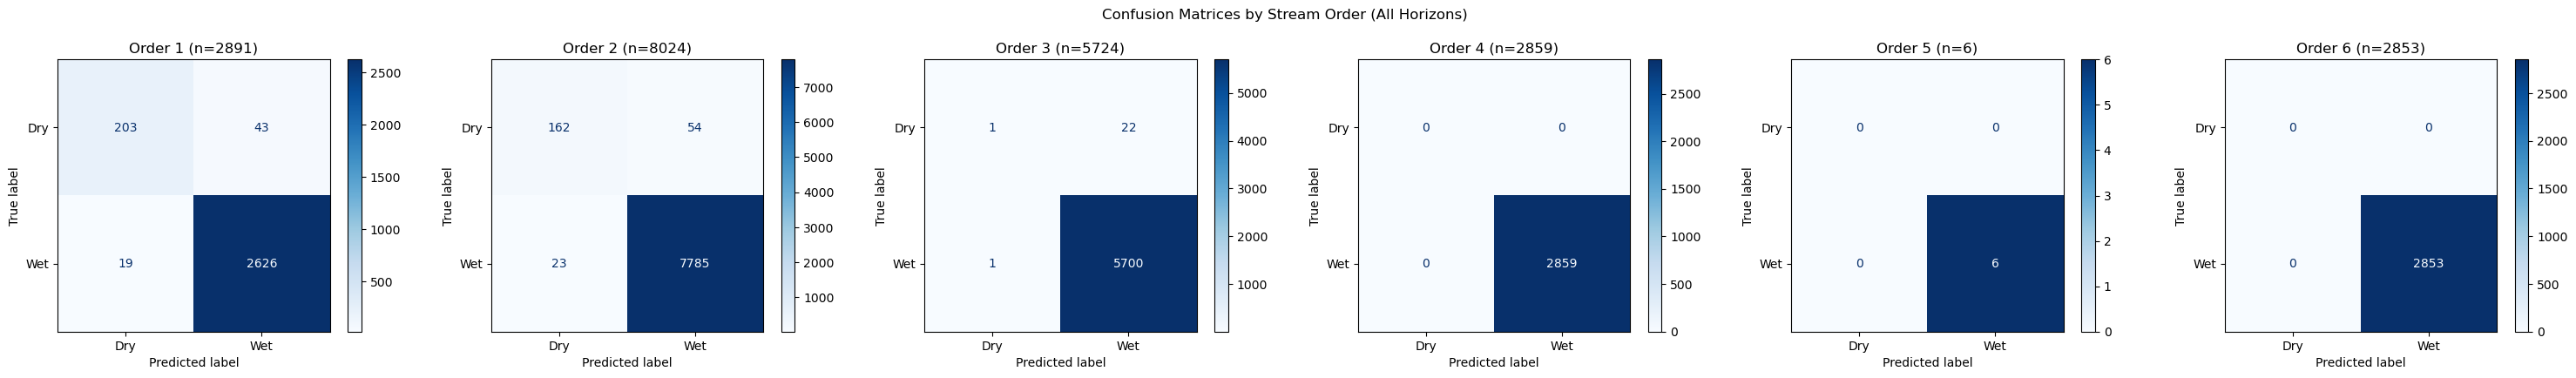

In [7]:
# Per stream order metrics (all horizons) + confusion matrices (aggregated)
order_values = sorted(
    horizon_dfs["All Horizons"]["StreamOrde"].dropna().unique().astype(int)
)

for h_name, h_df in horizon_dfs.items():
    rows = []
    for order in order_values:
        mask = h_df["StreamOrde"] == order
        if mask.sum() == 0:
            continue
        y_t = h_df.loc[mask, "true_wetdry"].values
        y_p = h_df.loc[mask, "pred_wetdry_label"].values
        acc, roc, f1_val = compute_metrics(y_t, y_p)
        rows.append({
            "Order": order, "N": int(mask.sum()),
            "Accuracy": acc, "ROC-AUC": roc, "F1": f1_val,
        })
    print(f"\n{'='*60}")
    print(f"Stream Order Breakdown — {h_name}")
    print("=" * 60)
    print(pd.DataFrame(rows).to_string(index=False))

# Confusion matrices per order (All Horizons)
agg_df = horizon_dfs["All Horizons"]
n_orders = len(order_values)
fig, axes = plt.subplots(1, n_orders, figsize=(5 * n_orders, 4))
if n_orders == 1:
    axes = [axes]

for idx, order in enumerate(order_values):
    ax = axes[idx]
    mask = agg_df["StreamOrde"] == order
    if mask.sum() == 0:
        ax.set_visible(False)
        continue
    y_t = agg_df.loc[mask, "true_wetdry"].values
    y_p = agg_df.loc[mask, "pred_wetdry_label"].values
    cm = confusion_matrix(y_t, y_p, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Dry", "Wet"])
    disp.plot(cmap="Blues", values_format="d", ax=ax)
    ax.set_title(f"Order {order} (n={int(mask.sum())})")

plt.suptitle("Confusion Matrices by Stream Order (All Horizons)", y=1.02)
plt.tight_layout()
plt.show()

## HOBO vs Non-HOBO Site Breakdown (Day 3)

Compare model performance on HOBO sensor sites (discrete wet/dry observations) versus non-HOBO sites (continuous discharge, discretized to wet/dry). HOBO sites are identified as any site with at least one `HoboWetDry0.05` observation in `obs_df`.

HOBO sites in obs_df: 23
Day 3 val — HOBO: 1763, Non-HOBO: 5690, Total: 7453

ALL VALIDATION (n=7453)
Accuracy: 0.9933
ROC-AUC:  0.8819
F1 Score: 0.9966
              precision    recall  f1-score   support

         Dry      0.912     0.765     0.832       162
         Wet      0.995     0.998     0.997      7291

    accuracy                          0.993      7453
   macro avg      0.953     0.882     0.914      7453
weighted avg      0.993     0.993     0.993      7453


HOBO-ONLY VALIDATION (n=1763)
Accuracy: 0.9801
ROC-AUC:  0.8851
F1 Score: 0.9894
              precision    recall  f1-score   support

         Dry      0.921     0.775     0.842       120
         Wet      0.984     0.995     0.989      1643

    accuracy                          0.980      1763
   macro avg      0.952     0.885     0.916      1763
weighted avg      0.979     0.980     0.979      1763


NON-HOBO (DISCRETIZED) VALIDATION (n=5690)
Accuracy: 0.9974
ROC-AUC:  0.8687
F1 Score: 0.9987
              pr

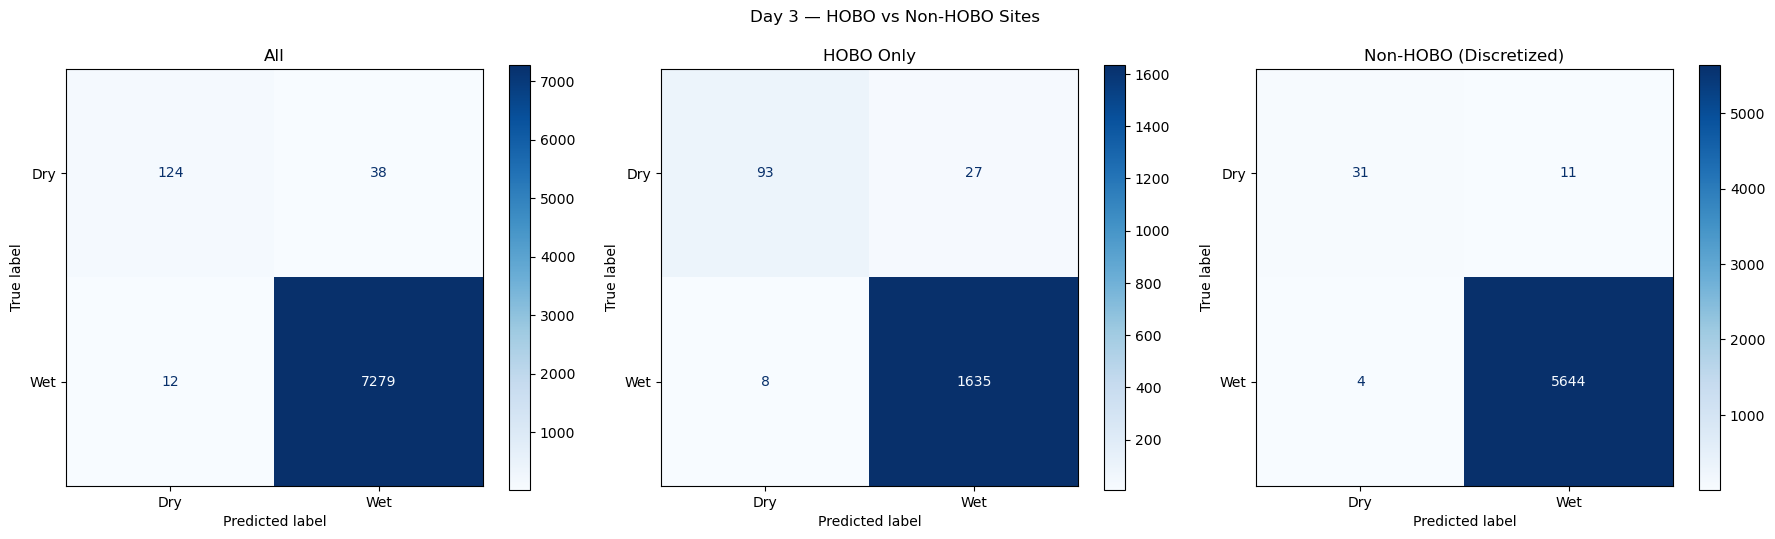

In [8]:
# Identify HOBO site IDs from obs_df
hobo_site_ids = set(
    obs_df[obs_df["variable"] == "HoboWetDry0.05"]["NHDPlusID"].astype(str)
)
print(f"HOBO sites in obs_df: {len(hobo_site_ids)}")

# Use Day 3 validation data
day3_val = horizon_dfs["Day 3"].copy()
day3_val["site_id_str"] = day3_val["site_id"].astype(str)
day3_val["is_hobo"] = day3_val["site_id_str"].isin(hobo_site_ids)

hobo_mask = day3_val["is_hobo"]
disc_mask = ~day3_val["is_hobo"]

print(f"Day 3 val — HOBO: {hobo_mask.sum()}, Non-HOBO: {disc_mask.sum()}, Total: {len(day3_val)}")

# Metrics per subset
def print_subset_metrics(name, subset):
    y_t = subset["true_wetdry"].values
    y_p = subset["pred_wetdry_label"].values
    acc, roc, f1_val = compute_metrics(y_t, y_p)
    print(f"\n{'='*50}")
    print(f"{name} (n={len(subset)})")
    print(f"{'='*50}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC:  {roc:.4f}")
    print(f"F1 Score: {f1_val:.4f}")
    print(classification_report(y_t, y_p, labels=[0, 1],
                                target_names=['Dry', 'Wet'], digits=3, zero_division=0))
    return acc, roc, f1_val

acc_all, roc_all, f1_all = print_subset_metrics("ALL VALIDATION", day3_val)
acc_hobo, roc_hobo, f1_hobo = print_subset_metrics("HOBO-ONLY VALIDATION", day3_val[hobo_mask])
acc_disc, roc_disc, f1_disc = print_subset_metrics("NON-HOBO (DISCRETIZED) VALIDATION", day3_val[disc_mask])

# Summary table
results_df = pd.DataFrame({
    'Validation Set': ['All', 'HOBO Only', 'Non-HOBO (Discretized)'],
    'N': [len(day3_val), int(hobo_mask.sum()), int(disc_mask.sum())],
    'Accuracy': [acc_all, acc_hobo, acc_disc],
    'ROC-AUC': [roc_all, roc_hobo, roc_disc],
    'F1': [f1_all, f1_hobo, f1_disc]
})
print(f"\n{'='*50}")
print("Summary")
print('='*50)
print(results_df.to_string(index=False))

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, subset) in zip(axes, [
    ('All', day3_val),
    ('HOBO Only', day3_val[hobo_mask]),
    ('Non-HOBO (Discretized)', day3_val[disc_mask])
]):
    y_t = subset["true_wetdry"].values
    y_p = subset["pred_wetdry_label"].values
    cm = confusion_matrix(y_t, y_p, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dry', 'Wet'])
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    ax.set_title(name)

plt.suptitle('Day 3 — HOBO vs Non-HOBO Sites', y=1.02)
plt.tight_layout()
plt.show()

## Perennial Status Estimation

Using RGCN **validation-set** predictions for the top 8 HOBO sites (by total observation count across all years), estimate perennial status via the proportion of wet predictions.

**USGS classification thresholds (predicted):**
- **Perennial**: wet fraction ≥ 0.96 (flows ≥96% of the time)
- **Intermittent**: wet fraction < 0.96

**NHD FCode ground truth:**
- 46006 → Perennial
- 46003 → Intermittent
- 55800 → Perennial (Artificial Path)

NHD Intermittent HOBO sites: 18
Mean wet fraction:   0.6484
Median wet fraction: 0.9548
Min: 0.0000  Max: 1.0000


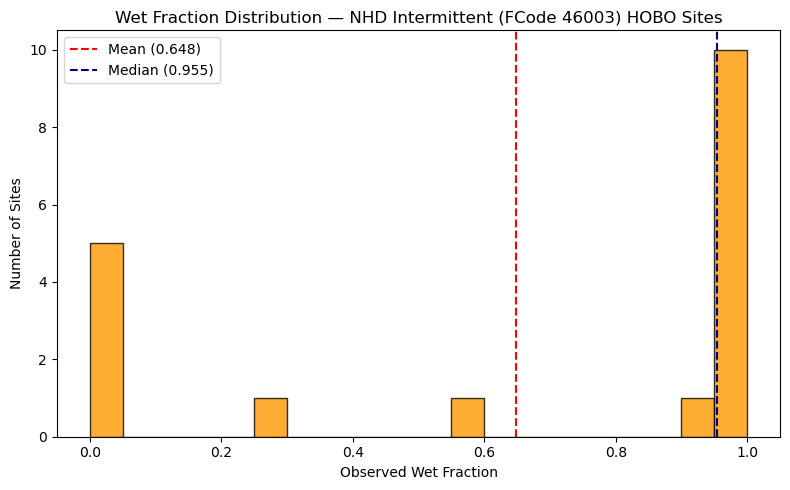

In [16]:
# Wet-fraction distribution for NHD-classified Intermittent HOBO sites
# FCode 46003 = Intermittent

df = day_1_df.copy()
df["date"] = pd.to_datetime(df["date"])
hobo_val = df[(df["true_wetdry"].notna())] # & (df["split"] == "val")]
hobo_val = hobo_val.merge(
    stream_order[["NHDPlusID", "StreamOrde", "FCode"]],
    left_on="site_id", right_on="NHDPlusID", how="left",
)

# Filter to NHD Intermittent sites (FCode 46003)
intermittent_val = hobo_val[hobo_val["FCode"] == 46003]

# Compute predicted wet fraction per site
# site_wet_frac = intermittent_val.groupby("site_id")["pred_wetdry_label"].mean()
site_wet_frac = intermittent_val.groupby("site_id")["true_wetdry"].mean()

print(f"NHD Intermittent HOBO sites: {len(site_wet_frac)}")
print(f"Mean wet fraction:   {site_wet_frac.mean():.4f}")
print(f"Median wet fraction: {site_wet_frac.median():.4f}")
print(f"Min: {site_wet_frac.min():.4f}  Max: {site_wet_frac.max():.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(site_wet_frac, bins=20, edgecolor="black", alpha=0.8, color="#FF9800")
ax.axvline(site_wet_frac.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean ({site_wet_frac.mean():.3f})")
ax.axvline(site_wet_frac.median(), color="navy", linestyle="--", linewidth=1.5, label=f"Median ({site_wet_frac.median():.3f})")
ax.set_xlabel("Observed Wet Fraction")
ax.set_ylabel("Number of Sites")
ax.set_title("Wet Fraction Distribution — NHD Intermittent (FCode 46003) HOBO Sites")
ax.legend()
plt.tight_layout()
plt.show()

### 3 Day 

Top 8 HOBO sites (by total obs) — val-set counts:
  55000900271031: 951 val obs  (of 4751 total)
  55000900061097: 951 val obs  (of 4751 total)
  55000900167704: 951 val obs  (of 4751 total)
  55000900029608: 951 val obs  (of 4751 total)
  55000900130309: 950 val obs  (of 4750 total)
  55000900234607: 950 val obs  (of 4749 total)
  55000900200040: 931 val obs  (of 4679 total)
  55000900029021: 787 val obs  (of 3899 total)


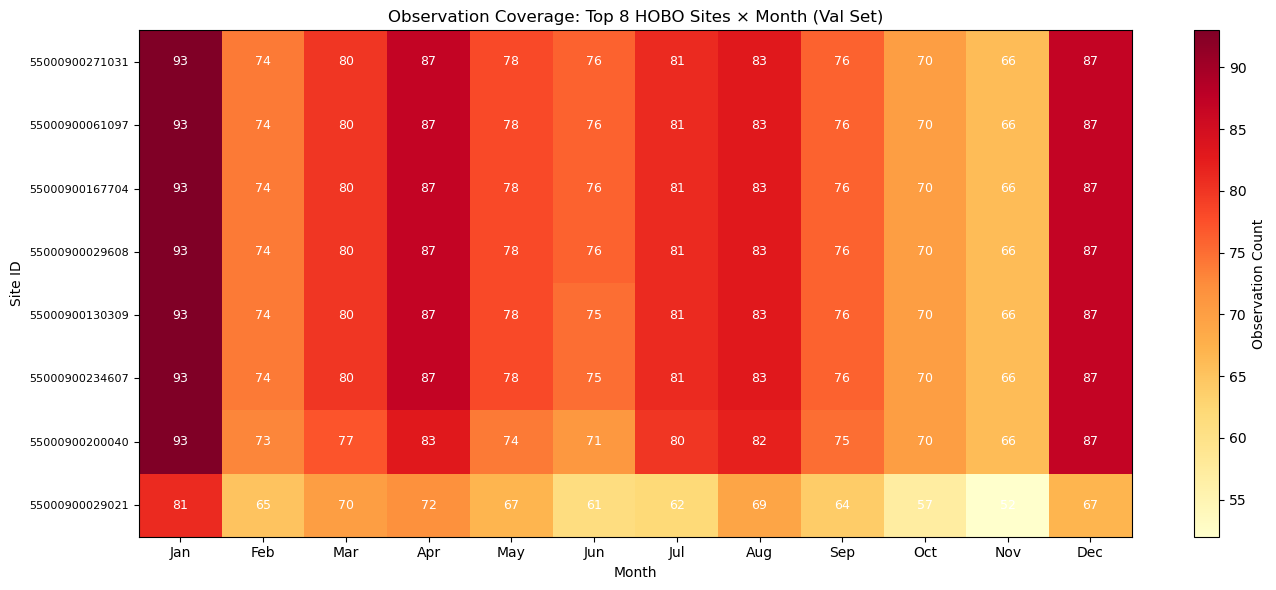

In [10]:
# Filter to HOBO sites (non-NaN true_wetdry), val split only
df = day_3_df.copy()
df["date"] = pd.to_datetime(df["date"])
hobo_val = df[(df["true_wetdry"].notna()) & (df["split"] == "val")]

# Top 8 HOBO sites by TOTAL observation count (across all years), then filter to val
hobo_all = df[df["true_wetdry"].notna()]
site_counts_all = hobo_all.groupby("site_id").size().sort_values(ascending=False)
top8_sites = site_counts_all.head(8).index.tolist()
top8_df = hobo_val[hobo_val["site_id"].isin(top8_sites)].copy()
top8_df = top8_df.merge(
    stream_order[["NHDPlusID", "StreamOrde", "FCode"]],
    left_on="site_id", right_on="NHDPlusID", how="left",
)

print("Top 8 HOBO sites (by total obs) — val-set counts:")
for site in top8_sites:
    n_total = (hobo_all["site_id"] == site).sum()
    n_val = (top8_df["site_id"] == site).sum()
    print(f"  {site}: {n_val} val obs  (of {n_total} total)")

# --- Monthly coverage heatmap (val set) ---
top8_df["month"] = top8_df["date"].dt.month
month_counts = top8_df.groupby(["site_id", "month"]).size().unstack(fill_value=0)
month_counts = month_counts.reindex(columns=range(1, 13), fill_value=0)
month_counts = month_counts.loc[[s for s in top8_sites if s in month_counts.index]]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(month_counts.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(12))
ax.set_xticklabels([calendar.month_abbr[m] for m in range(1, 13)])
ax.set_yticks(range(len(month_counts)))
ax.set_yticklabels(month_counts.index, fontsize=8)
ax.set_xlabel("Month")
ax.set_ylabel("Site ID")
ax.set_title("Observation Coverage: Top 8 HOBO Sites × Month (Val Set)")

for i in range(month_counts.shape[0]):
    for j in range(12):
        val = month_counts.values[i, j]
        ax.text(j, i, str(val), ha="center", va="center",
                color="white" if val > month_counts.values.max() / 2 else "black",
                fontsize=9)

plt.colorbar(im, ax=ax, label="Observation Count")
plt.tight_layout()
plt.show()

       Site ID  Order  FCode  N Obs  Pred Wet Frac  True Wet Frac  Est. Wet Days/Yr    Predicted  NHD (FCode)  Match
55000900167704      1  46003    951         0.9201         0.9222             335.8 Intermittent Intermittent   True
55000900271031      2  46003    951         0.9611         0.9600             350.8    Perennial Intermittent  False
55000900029021      2  46003    787         0.9657         0.9581             352.5    Perennial Intermittent  False
55000900029608      4  46006    951         1.0000         1.0000             365.0    Perennial    Perennial   True
55000900061097      6  55800    951         1.0000         1.0000             365.0    Perennial    Perennial   True
55000900234607      3  46006    950         1.0000         0.9989             365.0    Perennial    Perennial   True
55000900130309      3  46006    951         1.0000         0.9947             365.0    Perennial    Perennial   True
55000900200040      2  46006    930         1.0000         1.000

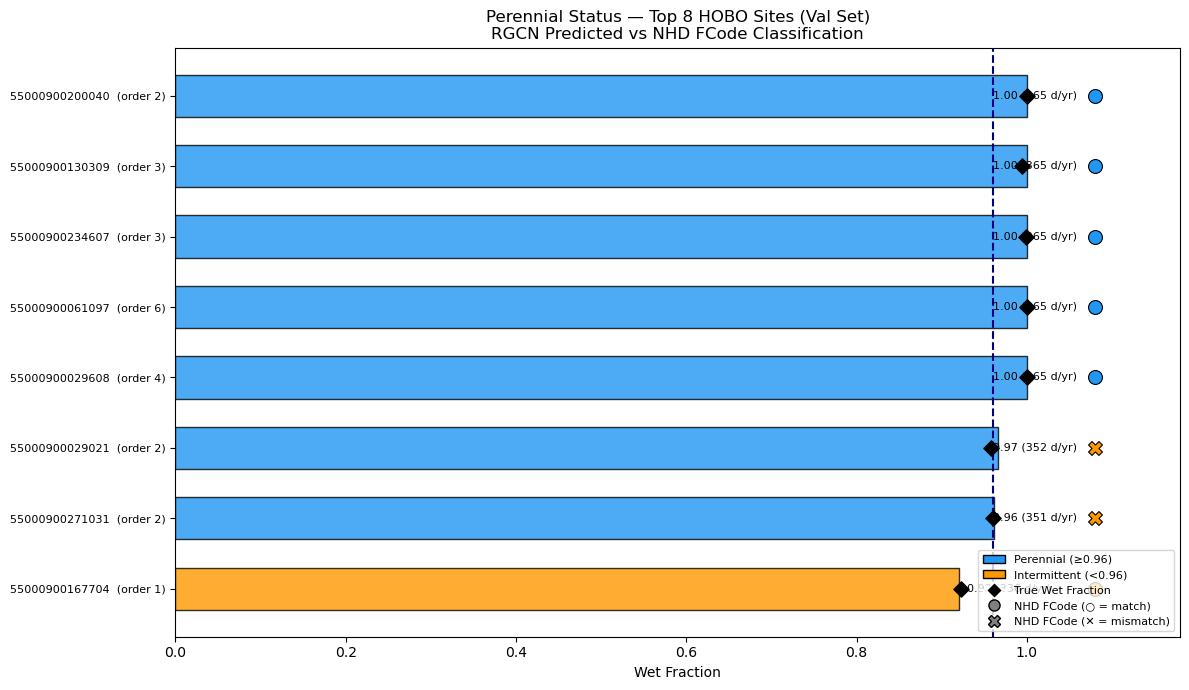

In [17]:
# Classify using predicted wet fraction and compare to NHD FCode
# Predicted:  Perennial if wet fraction ≥ threshold, else Intermittent
# FCode:      46006/55800 → Perennial,  46003 → Intermittent

FCODE_MAP = {46006: "Perennial", 46003: "Intermittent", 55800: "Perennial"}
threshold = 0.955

results = []
for site in top8_sites:
    site_data = top8_df[top8_df["site_id"] == site]
    n_obs = len(site_data)
    if n_obs == 0:
        continue
    wet_frac = site_data["pred_wetdry_label"].mean()
    true_wet_frac = site_data["true_wetdry"].mean()
    wet_days_est = wet_frac * 365
    order = site_data["StreamOrde"].iloc[0] if pd.notna(site_data["StreamOrde"].iloc[0]) else None
    fcode = site_data["FCode"].iloc[0] if pd.notna(site_data["FCode"].iloc[0]) else None

    pred_class = "Perennial" if wet_frac >= threshold else "Intermittent"
    nhd_class = FCODE_MAP.get(int(fcode), "Unknown") if fcode is not None else "Unknown"
    match = pred_class == nhd_class

    results.append({
        "Site ID": site, "Order": int(order) if order is not None else None,
        "FCode": int(fcode) if fcode is not None else None,
        "N Obs": n_obs, "Pred Wet Frac": round(wet_frac, 4),
        "True Wet Frac": round(true_wet_frac, 4),
        "Est. Wet Days/Yr": round(wet_days_est, 1),
        "Predicted": pred_class, "NHD (FCode)": nhd_class, "Match": match,
    })

results_df = pd.DataFrame(results).sort_values("Pred Wet Frac")
print(results_df.to_string(index=False))

n_match = results_df["Match"].sum()
print(f"\nAgreement: {n_match}/{len(results_df)} "
      f"({n_match / len(results_df):.0%})")

# --- Visualization ---
from matplotlib.patches import Patch

class_colors = {"Perennial": "#2196F3", "Intermittent": "#FF9800"}
fig, ax = plt.subplots(figsize=(12, 7))

y_pos = range(len(results_df))
bar_colors = [class_colors[c] for c in results_df["Predicted"]]

ax.barh(y_pos, results_df["Pred Wet Frac"], color=bar_colors,
        edgecolor="black", alpha=0.8, height=0.6, label="_nolegend_")

# True wet fraction
ax.scatter(results_df["True Wet Frac"], y_pos, color="black",
           marker="D", s=60, zorder=5)

# Threshold
ax.axvline(x=0.96, color="navy", linestyle="--", linewidth=1.5)

# NHD classification markers (border color on right edge)
for i, (_, row) in enumerate(results_df.iterrows()):
    nhd_color = class_colors.get(row["NHD (FCode)"], "gray")
    marker = "o" if row["Match"] else "X"
    ax.scatter(1.08, i, color=nhd_color, marker=marker, s=100,
               edgecolors="black", linewidths=0.8, zorder=5)

# Labels
site_labels = [
    f"{row['Site ID']}  (order {int(row['Order'])})" if pd.notna(row["Order"])
    else str(row["Site ID"])
    for _, row in results_df.iterrows()
]
ax.set_yticks(list(y_pos))
ax.set_yticklabels(site_labels, fontsize=8)
ax.set_xlabel("Wet Fraction")
ax.set_title("Perennial Status — Top 8 HOBO Sites (Val Set)\n"
             "RGCN Predicted vs NHD FCode Classification")
ax.set_xlim(0, 1.18)

# Annotate bars
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.text(min(row["Pred Wet Frac"] + 0.01, 0.96), i,
            f'{row["Pred Wet Frac"]:.2f} ({row["Est. Wet Days/Yr"]:.0f} d/yr)',
            va="center", fontsize=8)

legend_elements = [
    Patch(facecolor=class_colors["Perennial"], edgecolor="black", label="Perennial (≥0.96)"),
    Patch(facecolor=class_colors["Intermittent"], edgecolor="black", label="Intermittent (<0.96)"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="black",
               markersize=8, label="True Wet Fraction"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
               markeredgecolor="black", markersize=8, label="NHD FCode (○ = match)"),
    plt.Line2D([0], [0], marker="X", color="w", markerfacecolor="gray",
               markeredgecolor="black", markersize=8, label="NHD FCode (✕ = mismatch)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

### 1 Day

Top 8 HOBO sites (by total obs) — val-set counts:
  55000900029608: 951 val obs  (of 4751 total)
  55000900167704: 951 val obs  (of 4751 total)
  55000900061097: 951 val obs  (of 4751 total)
  55000900271031: 951 val obs  (of 4751 total)
  55000900234607: 950 val obs  (of 4750 total)
  55000900130309: 951 val obs  (of 4750 total)
  55000900200040: 930 val obs  (of 4678 total)
  55000900029021: 787 val obs  (of 3898 total)


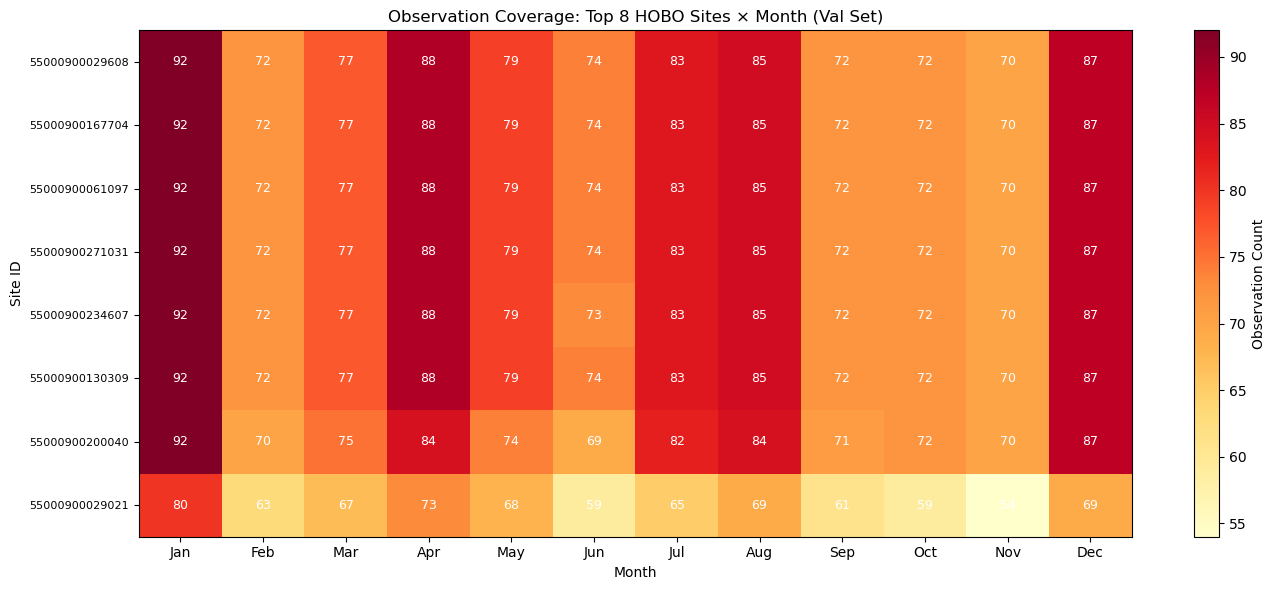

In [12]:
# Filter to HOBO sites (non-NaN true_wetdry), val split only
df = day_1_df.copy()
df["date"] = pd.to_datetime(df["date"])
hobo_val = df[(df["true_wetdry"].notna()) & (df["split"] == "val")]

# Top 8 HOBO sites by TOTAL observation count (across all years), then filter to val
hobo_all = df[df["true_wetdry"].notna()]
site_counts_all = hobo_all.groupby("site_id").size().sort_values(ascending=False)
top8_sites = site_counts_all.head(8).index.tolist()
top8_df = hobo_val[hobo_val["site_id"].isin(top8_sites)].copy()
top8_df = top8_df.merge(
    stream_order[["NHDPlusID", "StreamOrde", "FCode"]],
    left_on="site_id", right_on="NHDPlusID", how="left",
)

print("Top 8 HOBO sites (by total obs) — val-set counts:")
for site in top8_sites:
    n_total = (hobo_all["site_id"] == site).sum()
    n_val = (top8_df["site_id"] == site).sum()
    print(f"  {site}: {n_val} val obs  (of {n_total} total)")

# --- Monthly coverage heatmap (val set) ---
top8_df["month"] = top8_df["date"].dt.month
month_counts = top8_df.groupby(["site_id", "month"]).size().unstack(fill_value=0)
month_counts = month_counts.reindex(columns=range(1, 13), fill_value=0)
month_counts = month_counts.loc[[s for s in top8_sites if s in month_counts.index]]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(month_counts.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(12))
ax.set_xticklabels([calendar.month_abbr[m] for m in range(1, 13)])
ax.set_yticks(range(len(month_counts)))
ax.set_yticklabels(month_counts.index, fontsize=8)
ax.set_xlabel("Month")
ax.set_ylabel("Site ID")
ax.set_title("Observation Coverage: Top 8 HOBO Sites × Month (Val Set)")

for i in range(month_counts.shape[0]):
    for j in range(12):
        val = month_counts.values[i, j]
        ax.text(j, i, str(val), ha="center", va="center",
                color="white" if val > month_counts.values.max() / 2 else "black",
                fontsize=9)

plt.colorbar(im, ax=ax, label="Observation Count")
plt.tight_layout()
plt.show()

       Site ID  Order  FCode  N Obs  Pred Wet Frac  True Wet Frac  Est. Wet Days/Yr    Predicted  NHD (FCode)  Match
55000900167704      1  46003    951         0.9201         0.9222             335.8 Intermittent Intermittent   True
55000900271031      2  46003    951         0.9611         0.9600             350.8    Perennial Intermittent  False
55000900029021      2  46003    787         0.9657         0.9581             352.5    Perennial Intermittent  False
55000900029608      4  46006    951         1.0000         1.0000             365.0    Perennial    Perennial   True
55000900061097      6  55800    951         1.0000         1.0000             365.0    Perennial    Perennial   True
55000900234607      3  46006    950         1.0000         0.9989             365.0    Perennial    Perennial   True
55000900130309      3  46006    951         1.0000         0.9947             365.0    Perennial    Perennial   True
55000900200040      2  46006    930         1.0000         1.000

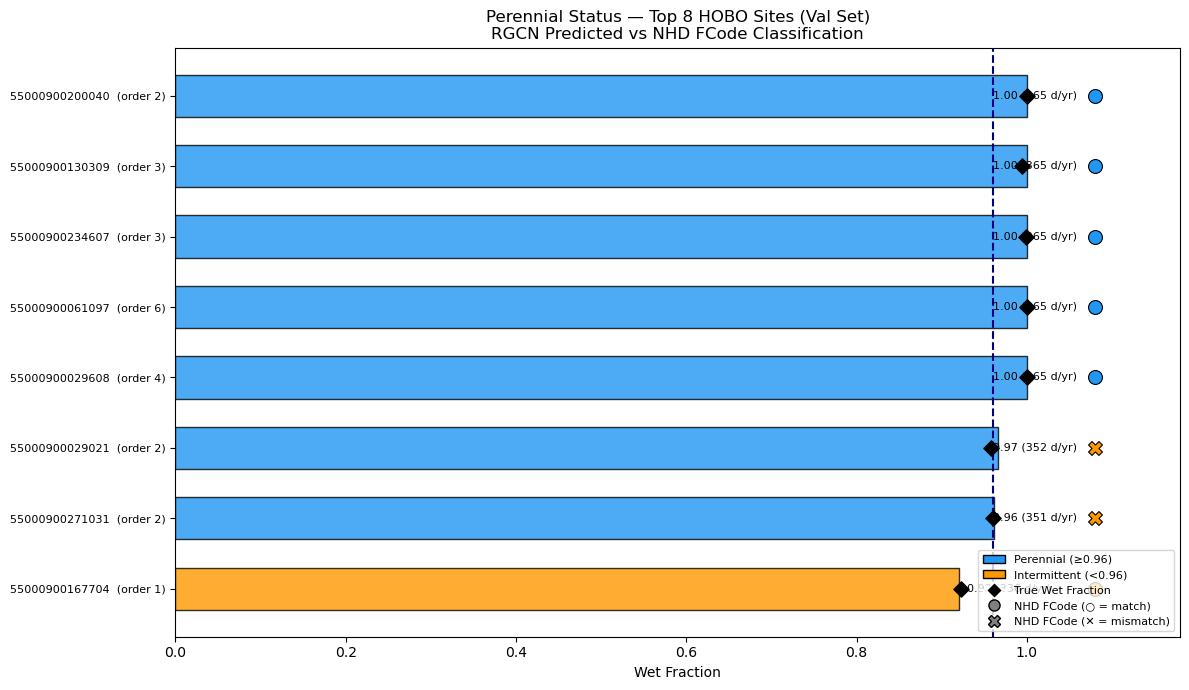

In [18]:
# Classify using predicted wet fraction and compare to NHD FCode
# Predicted:  Perennial if wet fraction ≥ threshold, else Intermittent
# FCode:      46006/55800 → Perennial,  46003 → Intermittent

FCODE_MAP = {46006: "Perennial", 46003: "Intermittent", 55800: "Perennial"}
threshold = 0.955

results = []
for site in top8_sites:
    site_data = top8_df[top8_df["site_id"] == site]
    n_obs = len(site_data)
    if n_obs == 0:
        continue
    wet_frac = site_data["pred_wetdry_label"].mean()
    true_wet_frac = site_data["true_wetdry"].mean()
    wet_days_est = wet_frac * 365
    order = site_data["StreamOrde"].iloc[0] if pd.notna(site_data["StreamOrde"].iloc[0]) else None
    fcode = site_data["FCode"].iloc[0] if pd.notna(site_data["FCode"].iloc[0]) else None

    pred_class = "Perennial" if wet_frac >= threshold else "Intermittent"
    nhd_class = FCODE_MAP.get(int(fcode), "Unknown") if fcode is not None else "Unknown"
    match = pred_class == nhd_class

    results.append({
        "Site ID": site, "Order": int(order) if order is not None else None,
        "FCode": int(fcode) if fcode is not None else None,
        "N Obs": n_obs, "Pred Wet Frac": round(wet_frac, 4),
        "True Wet Frac": round(true_wet_frac, 4),
        "Est. Wet Days/Yr": round(wet_days_est, 1),
        "Predicted": pred_class, "NHD (FCode)": nhd_class, "Match": match,
    })

results_df = pd.DataFrame(results).sort_values("Pred Wet Frac")
print(results_df.to_string(index=False))

n_match = results_df["Match"].sum()
print(f"\nAgreement: {n_match}/{len(results_df)} "
      f"({n_match / len(results_df):.0%})")

# --- Visualization ---
from matplotlib.patches import Patch

class_colors = {"Perennial": "#2196F3", "Intermittent": "#FF9800"}
fig, ax = plt.subplots(figsize=(12, 7))

y_pos = range(len(results_df))
bar_colors = [class_colors[c] for c in results_df["Predicted"]]

ax.barh(y_pos, results_df["Pred Wet Frac"], color=bar_colors,
        edgecolor="black", alpha=0.8, height=0.6, label="_nolegend_")

# True wet fraction
ax.scatter(results_df["True Wet Frac"], y_pos, color="black",
           marker="D", s=60, zorder=5)

# Threshold
ax.axvline(x=0.96, color="navy", linestyle="--", linewidth=1.5)

# NHD classification markers (border color on right edge)
for i, (_, row) in enumerate(results_df.iterrows()):
    nhd_color = class_colors.get(row["NHD (FCode)"], "gray")
    marker = "o" if row["Match"] else "X"
    ax.scatter(1.08, i, color=nhd_color, marker=marker, s=100,
               edgecolors="black", linewidths=0.8, zorder=5)

# Labels
site_labels = [
    f"{row['Site ID']}  (order {int(row['Order'])})" if pd.notna(row["Order"])
    else str(row["Site ID"])
    for _, row in results_df.iterrows()
]
ax.set_yticks(list(y_pos))
ax.set_yticklabels(site_labels, fontsize=8)
ax.set_xlabel("Wet Fraction")
ax.set_title("Perennial Status — Top 8 HOBO Sites (Val Set)\n"
             "RGCN Predicted vs NHD FCode Classification")
ax.set_xlim(0, 1.18)

# Annotate bars
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.text(min(row["Pred Wet Frac"] + 0.01, 0.96), i,
            f'{row["Pred Wet Frac"]:.2f} ({row["Est. Wet Days/Yr"]:.0f} d/yr)',
            va="center", fontsize=8)

legend_elements = [
    Patch(facecolor=class_colors["Perennial"], edgecolor="black", label="Perennial (≥0.96)"),
    Patch(facecolor=class_colors["Intermittent"], edgecolor="black", label="Intermittent (<0.96)"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="black",
               markersize=8, label="True Wet Fraction"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
               markeredgecolor="black", markersize=8, label="NHD FCode (○ = match)"),
    plt.Line2D([0], [0], marker="X", color="w", markerfacecolor="gray",
               markeredgecolor="black", markersize=8, label="NHD FCode (✕ = mismatch)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()